**4장 - 모델 훈련**

# 설정

이 프로젝트는 파이썬 3.7 이상이 필요함

In [2]:
import sys

assert sys.version_info >= (3, 7)

또한 사이킷런 ≥ 1.0.1이 필요합니다:

In [1]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

기본 글꼴 크기 정의 :

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

이미지 path 지정: 

In [5]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "training_linear_models"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 선형 회귀

일반적인 선형 모델은 
$$
\hat{y} = \theta _0 + \theta _1 x_1 + \theta _2 x_2 + ... + \theta _n x_n
$$

선형 회귀 모델의 예측 식처럼 익렵 특성의 가중치 합과 **편향(bias)** (또는 **절편(intercept)**)이라는 상수를 더해 예측함
 
- $ \hat{y} $ : 예측값
- $ n $ : 특성의 수
- $ x_i $ : $i$번째 특성값
- $ \theta _j $ : $j$번째 모델 파라미터

이 식은 

$$
\hat{y}
= h_{\boldsymbol{\theta}}(\mathbf{x})
= \boldsymbol{\theta} \cdot \mathbf{x}
$$

이처럼 벡터 형태로 더 간단하게 쓸 수 있음.

- $h_0$ : 모델 파라미터 $\boldsymbol{\theta}$를 사용한 가설 함수
- $\boldsymbol{\theta}$ : 편향 $\theta _0$과 $\theta _1$에서 $\theta _n$까지의 가중치를 담은 모델의 파라미터 벡터
- $\boldsymbol{x}$ : $x_0$에서 $x_n$까지 담은 샘플의 **특성 벡터**. $x_0$은 항상 1
- $\boldsymbol{\theta} \cdot \boldsymbol{x}$ : 벡터 $\boldsymbol{\theta}$ 와 $\boldsymbol{x_0}$의 점곱. $\theta _0 + \theta _1 x_1 + \theta _2 x_2 + ... + \theta _n x_n$ 과 같음


모델을 훈련시킨 다는 것은 모델이 훈련 세트에 가장 잘 맞도록 모델 파라미터를 설정하는 것.

이를 하기 위해서 먼저 모델이 훈련 데이터에 얼마나 잘 맞는지 측정해야함. 회귀에서 가장 널리 사용되는 성능 측정 지표는 **평균 제곱츤 고차 (RMSE)**.
그러므로 선형 회귀 모델을 훈련시키기려면 RMSE를 최소화 하는 $\boldsymbol{\theta}$를 찾아야함.

훈련 세트 $\boldsymbol{X}$ 에 대한 선형 회귀 가서 $h_0$의 MSE는 아래와 같이 계산함.
$$
MSE(\boldsymbol{X}, h_\theta) = \frac{1}{m} \sum_{i=1}^{m}(\boldsymbol{\theta}^T \boldsymbol{x}^{(i)} - y^{i})^{2}
$$
이 계산식에서는 $MSE(\boldsymbol{X}, h_\theta)$ 대신 $MSE(\boldsymbol{\theta})$ 표시가능

## 정규 방정식

비용 함수를 최소화 하는 $\boldsymbol{\theta}$ 값을 찾기 위한 **해석적인 방법**이 있음.다른 말로 하면 결과를 바로 얻을 수 있느 수학 공식이 있음. 이를 **정규 방정식(normal equation)** 이라고 함

정규 방정식:
$$
\hat{\boldsymbol{\theta}} = (\boldsymbol{X}^{T} \boldsymbol{X})^{-1} \boldsymbol{X}^T \boldsymbol{y}
$$

- $\hat{\boldsymbol{\theta}}$ : 비용 함수를 최소화하는 $\boldsymbol{\theta}$ 값
- $\boldsymbol{y}$ : $y^{(1)}$ 부터 $y^{(m)}$ 까지 포함하는 타깃 벡터

공식 테스트를 위한 선형 처럼 보이는 데이터 생성 : 

In [6]:
import numpy as np

np.random.seed(42)
m = 100  # 샘플 개수
X = 2 * np.random.rand(m, 1)  # 열 벡터
y = 4 + 3 * X + np.random.randn(m, 1)  # 열 벡터

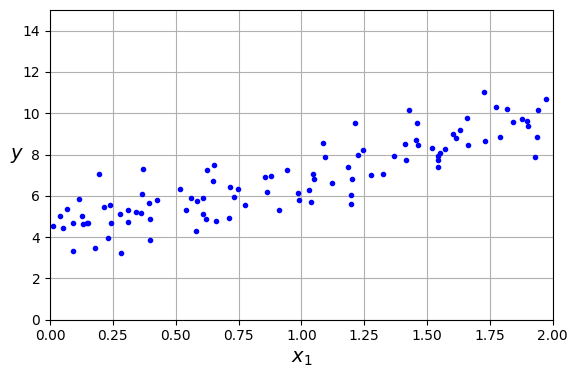

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
save_fig("generated_data_plot")
plt.show()

정규 방정식을 사용해 $\hat{\boldsymbol{\theta}}$를 계산하는 코드 :

In [8]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # 각 샘플에 x0 = 1을 추가합니다.
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [9]:
theta_best

array([[4.21509616],
       [2.77011339]])

 $\hat{\boldsymbol{\theta}}$ 을 사용해 예측 : 

In [11]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # 각 샘플에 x0 = 1을 추가
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

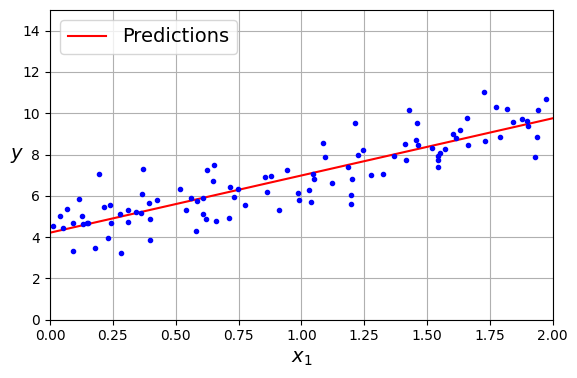

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
save_fig("linear_model_predictions_plot")

plt.show()

In [13]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [14]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

`LinearRegression` 클래스는 `scipy.linalg.lstsq()` 함수("least squares"의 약자)를 사용하므로 이 함수를 직접 사용할 수 있음:

In [15]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

이 함수는 $\hat{\mathbf{\theta}} = \mathbf{X}^+\mathbf{y}$을 계산함. $\mathbf{X}^{+}$는 $\mathbf{X}$의 **유사역행렬 (pseudoinverse)** 임. ( 정확하게는 Moore–Penrose 유사역행렬). `np.linalg.pinv()`을 사용해서 유사역행렬을 직접 계산할 수 있습니다:

In [16]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

유사역행렬 자체는 **특잇값 분해(singular value decomposition, SVD)** 라 부르는 표준 행렬 분해 기법을 사용해 계산됨. 

SVD는 훈련 세트 행렬 $\boldsymbol{X}$ 를 3개의 행렬곱셈 $\mathbf{U}\mathbf{\Sigma}\mathbf{V}^{T}$로 분해함

유사 역행렬은 $\mathbf{X}^{+} = \mathbf{V} \mathbf{\Sigma}^{+} \mathbf{U}^{T}$로  계산됨.

$\mathbf{\Sigma}^{+}$를 계산하기 위해 알고리즘이  $\mathbf{\Sigma}$를 먼저 구한 다음 어떤 낮은 임곗값 보다 작은 수를 0으로 바꿈. 그 다음 0이아닌 모든 값을 역수로 치환, 마지막으로 만들어진 행렬을 전치함. 

정규 방정식을 계산하는 것보다 이 방식이 훨씬 효율적임. 또한 극단적인 경우도 처리할 수 있음.

실제로 $m<n$ 이거나 어떤 특성이 중복되어 행렬 $\mathbf{X}^{T} \mathbf{X}$의 역행렬이 없다면 정규 방정식이 작동하지 않음. 하지만 유사역행렬은 항상 구할 수 있음.

## 계산 복잡도

정규 방정식은 $(n + 1) \times (n+1)$ 크기의 $\mathbf{X}^T \mathbf{X}$의 역행렬을 계산함.($n$은 특성의 수) 일반적으로 역행렬을 계산하는 **시간 복잡도 (computational complexity)** 는 일반적으로 $O(n^{2.4})$ 에서 $O(n^{3})$ 사이임. (구현 방법에 따라 차이가 있음.) 즉, 특성 수가 두 배로 늘어나면 계산 시간이 대략 $2^{2.4} = 5.3$배 에서 $2^{3} = 8$배로 늘어날 수 있음.

정리하자면 샘플링의 개수에따라 훈련시간이 배로 늘어남